In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

random_state = 42

# Week 8 - K-Nearest Neighbors

In [3]:
cancer_deaths = pd.read_csv('../Processed Data/cdc_cancer_deaths_encoded.csv')
cancer_deaths.head()

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:
# fixing data leakage (SEX_CODED_F and cancer types that accurately leak the sex of the patient)
X = cancer_deaths.drop(columns=['SEX_Female', 'SEX_Male', 'SEX_CODED_F', 'CAUSE_OF_DEATH_Malignant neoplasm of breast (C50)', 'CAUSE_OF_DEATH_Malignant neoplasm of prostate (C61)', 'CAUSE_OF_DEATH_Malignant neoplasm of ovary (C56)', 'CAUSE_OF_DEATH_Malignant neoplasms of corpus uteri and uterus, part unspecified (C54-C55)', 'CAUSE_OF_DEATH_Malignant neoplasm of cervix uteri (C53)', 'CAUSE_RECODE_113'])
y = cancer_deaths['SEX_Female']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [ ]:
X_train.shape

(1262791, 108)

In [ ]:
# Baseline KNN model

baseline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=10,
        algorithm='brute',
        metric='euclidean',
        weights='uniform',
        n_jobs=-1
    ))
])

In [ ]:
baseline_knn.fit(X_train, y_train)

print("Quick Test Accuracy:", baseline_knn.score(X_test.iloc[:5000], y_test.iloc[:5000]))


Quick Test Accuracy: 0.6494


In [ ]:
print(y_train.value_counts(normalize=True))

SEX_Female
0.0    0.526983
1.0    0.473017
Name: proportion, dtype: float64


In [ ]:
# Calculate correlation of all features with the target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(correlations.head(20))

MARITAL_STATUS_Widowed                                                           0.230913
MARITAL_STATUS_Married                                                           0.204137
CAUSE_OF_DEATH_Malignant neoplasm of esophagus (C15)                             0.096020
CAUSE_OF_DEATH_Malignant neoplasm of bladder (C67)                               0.069348
CAUSE_OF_DEATH_Malignant neoplasms of liver and intrahepatic bile ducts (C22)    0.066110
CAUSE_OF_DEATH_Malignant neoplasms of lip, oral cavity and pharynx (C00-C14)     0.051003
CAUSE_OF_DEATH_Malignant neoplasm of larynx (C32)                                0.046766
CAUSE_OF_DEATH_Malignant neoplasms of kidney and renal pelvis (C64-C65)          0.043628
PLACE_OF_DEATH_CODED                                                             0.041785
CAUSE_OF_DEATH_Malignant melanoma of skin (C43)                                  0.031145
EDUCATION_Advanced Degree                                                        0.030144
EDUCATION_

Text(0.5, 1.0, 'KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

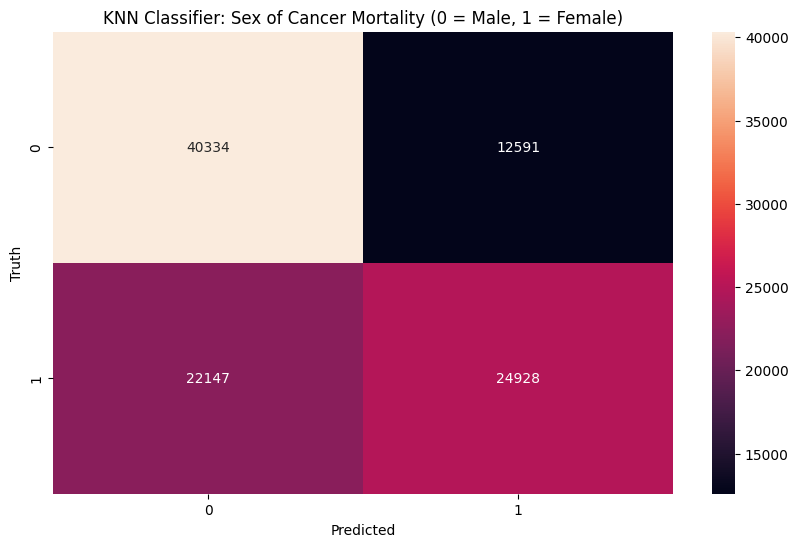

In [ ]:
y_pred = baseline_knn.predict(X_test.iloc[:100_000])
cm = confusion_matrix(y_test.iloc[:100_000], y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

In [ ]:
print(classification_report(y_test.iloc[:100_000], y_pred))

              precision    recall  f1-score   support

         0.0       0.65      0.76      0.70     52925
         1.0       0.66      0.53      0.59     47075

    accuracy                           0.65    100000
   macro avg       0.65      0.65      0.64    100000
weighted avg       0.65      0.65      0.65    100000



Findings:
  - Less true predctions for Female (24,928) than Male (40,334)
  - More inaccurate predictions for Male (22,147) than Female (12,591)
  - Overall accuracy of 65% for the first 100,000 samples in the sample splits
  - Baseline model has a bias towards Male classifications. This could be due to a lack of hypertuning and also that the first 100,000 samples from the split were taken rather than a stratified sample of the split that maintains the original ratio of Male and Female samples.

Text(0.5, 1.0, 'KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

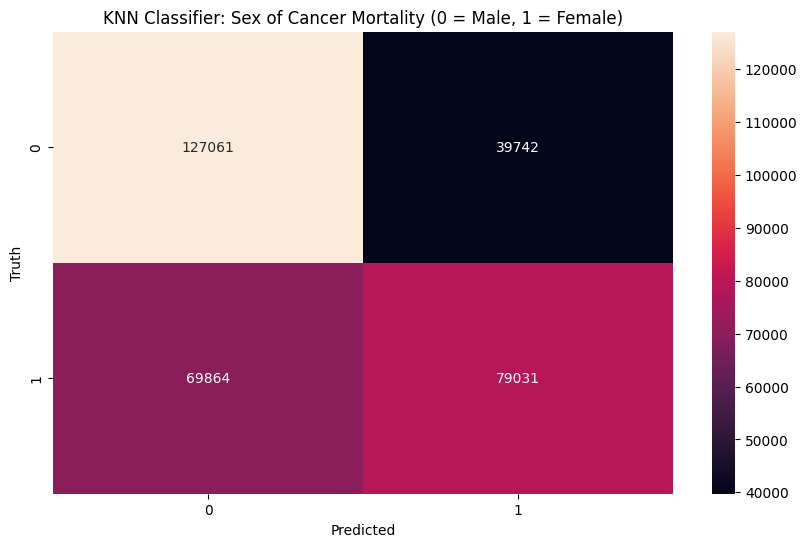

In [ ]:
y_pred = baseline_knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

In [ ]:
len(X_train)

1262791

In [ ]:
0.05 * len(X_train)

63139.55

In [ ]:
X_search, _, y_search, _ = train_test_split(X_train, y_train, train_size=0.05, stratify=y_train, random_state=random_state)

tuned_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(algorithm='brute', n_jobs=-1))
])

param_grid = {
    'knn__n_neighbors': [5, 10, 25, 50, 100],
    'knn__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=tuned_knn,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print(f"Running Grid Search on {len(X_search)} samples")
grid_search.fit(X_search, y_search)

print("Best Parameters Found:", grid_search.best_params_)
print(f"Best GS CV Score (Macro F1): {grid_search.best_score_}")

Running Grid Search on 63139 samples
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'knn__n_neighbors': 100, 'knn__weights': 'distance'}
Best GS CV Score (Macro F1): 0.645090319152501


In [ ]:
final_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=100,
        weights='distance',
        algorithm='brute',
        n_jobs=-1))
])

print(f"Fitting the hypertuned model on the full training set ({len(X_train):,.0f} samples)")
final_knn.fit(X_train, y_train)

Fitting the hypertuned model on the full training set (1,262,791 samples)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(algorithm='brute', n_jobs=-1,
                                      n_neighbors=100, weights='distance'))])

Text(0.5, 1.0, 'Hypertuned KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

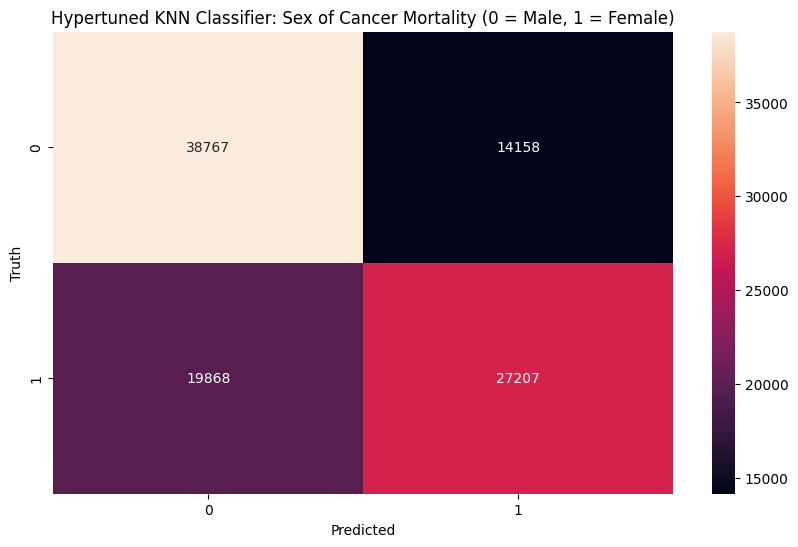

In [ ]:
y_pred_final = final_knn.predict(X_test.iloc[:100_000])
cm = confusion_matrix(y_test.iloc[:100_000], y_pred_final)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Hypertuned KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

In [ ]:
print(classification_report(y_test.iloc[:100_000], y_pred_final))

              precision    recall  f1-score   support

         0.0       0.66      0.73      0.69     52925
         1.0       0.66      0.58      0.62     47075

    accuracy                           0.66    100000
   macro avg       0.66      0.66      0.66    100000
weighted avg       0.66      0.66      0.66    100000



The model's accuracy is basically the same with hypertuning (difference of 1%).

#### KNN with feature selection

In [5]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [22]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [26]:
# Baseline model with k-best features
baseline_knn_new = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=25)),
    ('knn', KNeighborsClassifier(
        n_neighbors=10,
        algorithm='brute',
        metric='euclidean',
        weights='uniform',
        n_jobs=-1
    ))
])

In [27]:
baseline_knn_new.fit(X_train_new, y_train_new)

print("Quick Test Accuracy:", baseline_knn_new.score(X_test_new.iloc[:5000], y_test_new.iloc[:5000]))


Quick Test Accuracy: 0.6154


Text(0.5, 1.0, 'KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

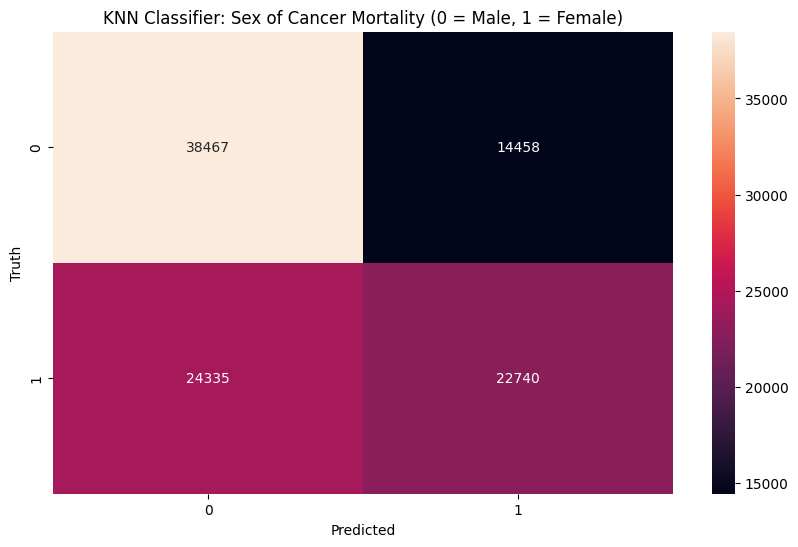

In [29]:
y_pred_new = baseline_knn_new.predict(X_test_new.iloc[:100_000])
cm_new = confusion_matrix(y_test.iloc[:100_000], y_pred_new)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_new, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

In [30]:
print(classification_report(y_test_new.iloc[:100_000], y_pred_new))

              precision    recall  f1-score   support

         0.0       0.61      0.73      0.66     52925
         1.0       0.61      0.48      0.54     47075

    accuracy                           0.61    100000
   macro avg       0.61      0.60      0.60    100000
weighted avg       0.61      0.61      0.61    100000



In [34]:
X_search_new, _, y_search_new, _ = train_test_split(X_train_new, y_train_new, train_size=0.05, stratify=y_train_new, random_state=random_state)

tuned_knn_new = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('knn', KNeighborsClassifier(algorithm='brute', weights='distance', n_jobs=-1))
])

param_grid = {
    'selector__k': [10, 25, 50, 75],
    'knn__n_neighbors': [5, 10, 25, 50, 100]
}

grid_search_new = GridSearchCV(
    estimator=tuned_knn_new,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print(f"Running Grid Search on {len(X_search_new)} samples")
grid_search_new.fit(X_search_new, y_search_new)

print("Best Parameters Found:", grid_search_new.best_params_)
print(f"Best GS CV Score (Macro F1): {grid_search_new.best_score_}")

Running Grid Search on 63139 samples
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters Found: {'knn__n_neighbors': 100, 'selector__k': 75}
Best GS CV Score (Macro F1): 0.6327796407317351


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 17  21  22  33  35  36  37  38  39 100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [35]:
# Baseline model with k-best features
final_knn_new = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=75)),
    ('knn', KNeighborsClassifier(
        n_neighbors=100,
        algorithm='brute',
        metric='euclidean',
        weights='distance',
        n_jobs=-1
    ))
])

Text(0.5, 1.0, 'KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

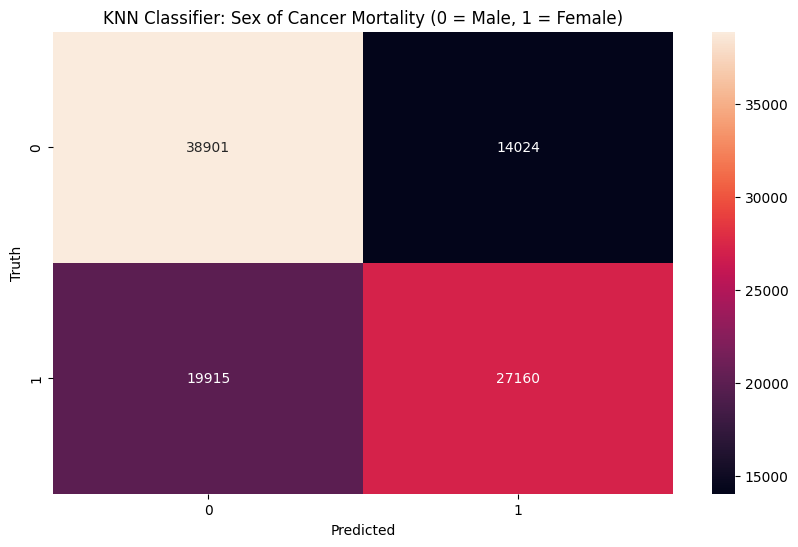

In [37]:
final_knn_new.fit(X_train_new, y_train_new)

y_pred_final_new = final_knn_new.predict(X_test_new.iloc[:100_000])
cm_new = confusion_matrix(y_test.iloc[:100_000], y_pred_final_new)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_new, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('KNN Classifier: Sex of Cancer Mortality (0 = Male, 1 = Female)')

In [38]:
print(classification_report(y_test_new.iloc[:100_000], y_pred_final_new))

              precision    recall  f1-score   support

         0.0       0.66      0.74      0.70     52925
         1.0       0.66      0.58      0.62     47075

    accuracy                           0.66    100000
   macro avg       0.66      0.66      0.66    100000
weighted avg       0.66      0.66      0.66    100000



Overall, this KBest KNN model performs relatively the same as the full X_train hypertuned KNN model. It was able to more accurately classify male mortalities (38,901 vs. 38,767), had slightly more inaccurate male classifications (19,915 vs. 19,868), had less inaccurate female classifications (14,024 vs. 14,158), and slightly less accurate female classifications (27,160 vs. 27,207). The strength of the KBest KNN model is that it reduced the complexity of the data by reducing the dimensions to 75 features versus 101 features. Both models had an accuracy of 66%.